HR Employee Attrition Prediction

1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print("All libraries imported successfully!")

All libraries imported successfully!


2. Load Dataset

In [2]:
import os

CSV_FILE = 'hr_attrition.csv'

if os.path.exists(CSV_FILE):
    df = pd.read_csv(CSV_FILE)
    print(f"Dataset loaded from CSV: {CSV_FILE}")

print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded from CSV: hr_attrition.csv

Dataset shape: 1470 rows × 35 columns


3. Exploratory Data Analysis (EDA)

In [3]:
print("=" * 60)
print("FIRST 5 ROWS OF THE DATASET")
print("=" * 60)
df.head()

FIRST 5 ROWS OF THE DATASET


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-nul

In [5]:
print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
df.describe()

STATISTICAL SUMMARY


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
print("=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

MISSING VALUES PER COLUMN
No missing values found!


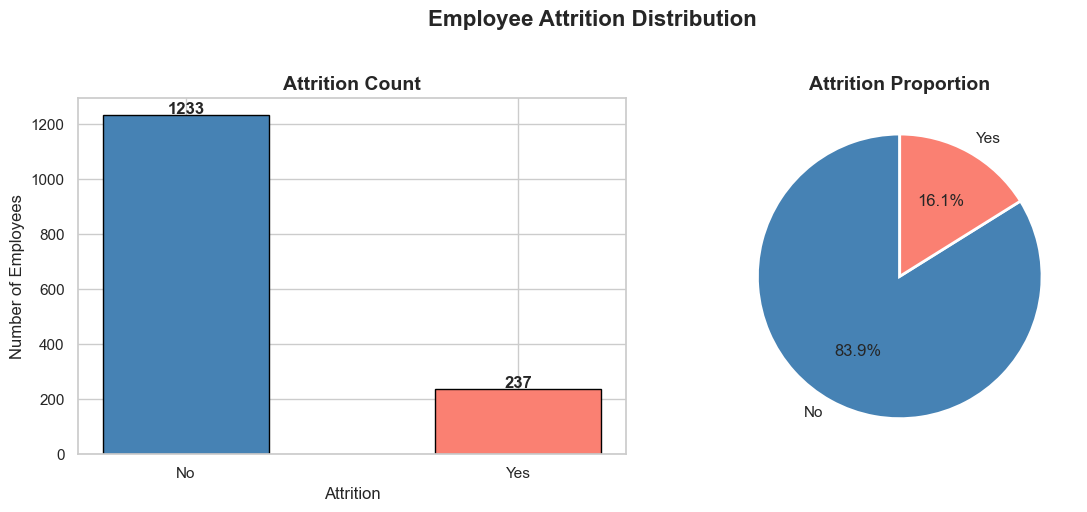


Attrition Rate: 16.12%
Insight: Dataset is imbalanced — more employees stayed than left.


In [7]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

attrition_counts = df['Attrition'].value_counts()
axes[0].bar(attrition_counts.index, attrition_counts.values,
            color=['steelblue', 'salmon'], edgecolor='black', width=0.5)
axes[0].set_title('Attrition Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of Employees')
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(attrition_counts.values, labels=attrition_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'salmon'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Attrition Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Employee Attrition Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nAttrition Rate: {round(attrition_counts.get('Yes',0)/len(df)*100, 2)}%")
print("Insight: Dataset is imbalanced — more employees stayed than left.")

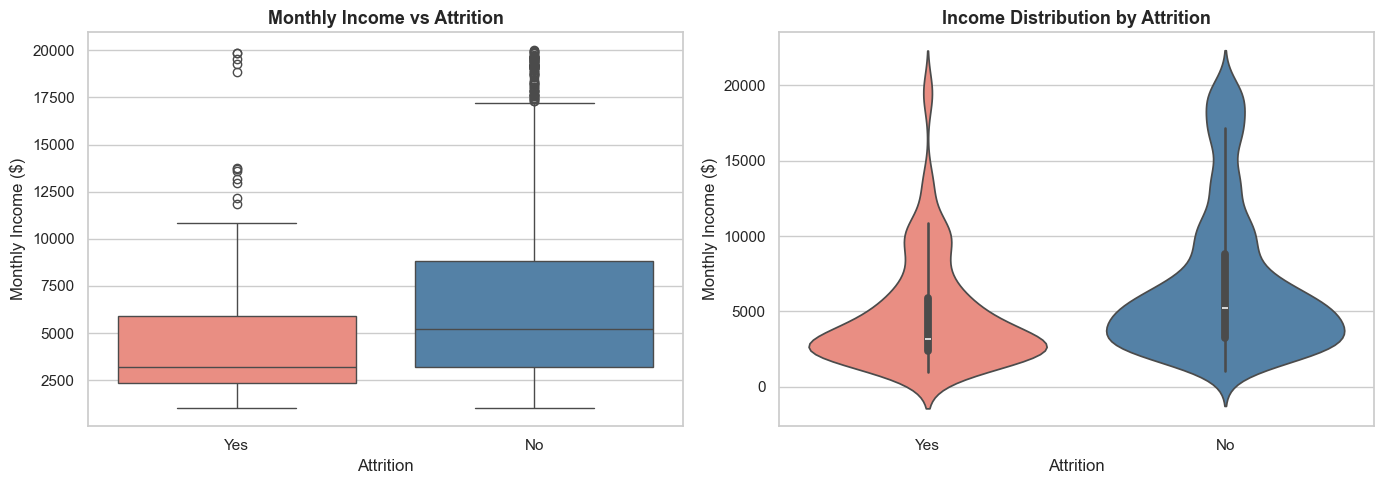


Average Monthly Income by Attrition:
Attrition
No     6832.74
Yes    4787.09
Name: MonthlyIncome, dtype: float64

Insight: Employees who left tend to have lower monthly income.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df,
            palette={'Yes': 'salmon', 'No': 'steelblue'}, ax=axes[0])
axes[0].set_title('Monthly Income vs Attrition', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Monthly Income ($)')

sns.violinplot(x='Attrition', y='MonthlyIncome', data=df,
               palette={'Yes': 'salmon', 'No': 'steelblue'}, ax=axes[1])
axes[1].set_title('Income Distribution by Attrition', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Monthly Income ($)')

plt.tight_layout()
plt.show()

avg_income = df.groupby('Attrition')['MonthlyIncome'].mean().round(2)
print("\nAverage Monthly Income by Attrition:")
print(avg_income)
print("\nInsight: Employees who left tend to have lower monthly income.")

<Figure size 1400x600 with 0 Axes>

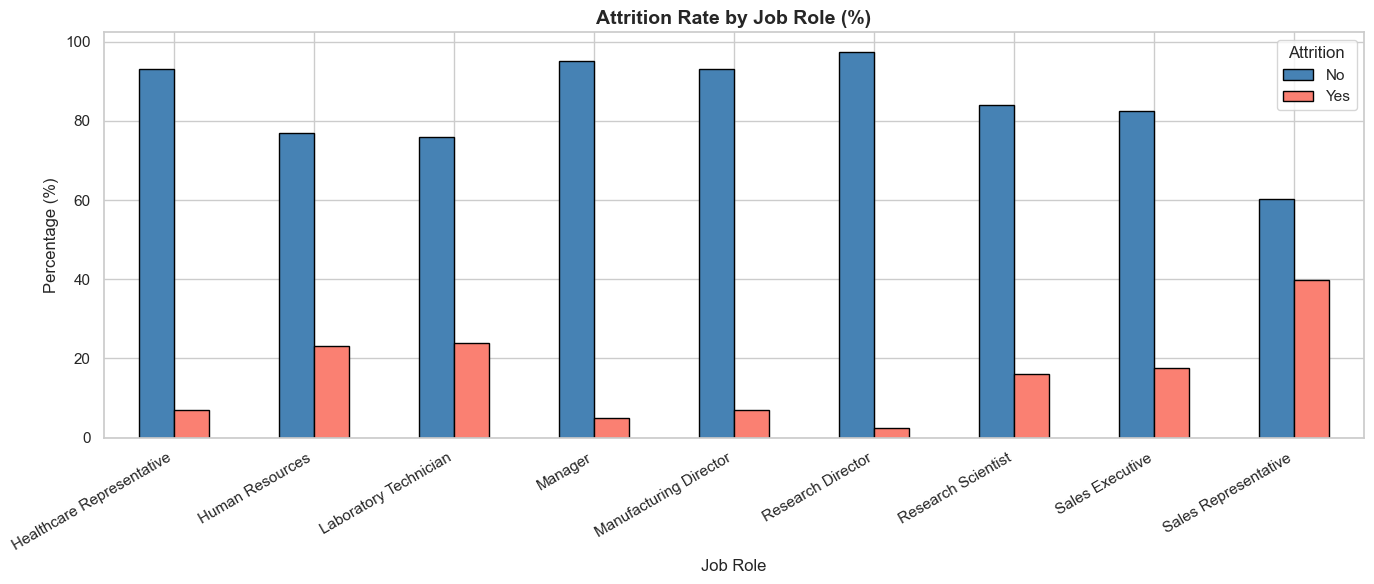


Top 3 Job Roles with Highest Attrition Rate:
   Sales Representative: 39.8%
   Laboratory Technician: 23.9%
   Human Resources: 23.1%


In [9]:
plt.figure(figsize=(14, 6))
role_attrition = df.groupby(['JobRole', 'Attrition']).size().unstack(fill_value=0)
role_attrition_pct = role_attrition.div(role_attrition.sum(axis=1), axis=0) * 100

role_attrition_pct.plot(kind='bar', color=['steelblue', 'salmon'],
                         edgecolor='black', figsize=(14, 6))
plt.title('Attrition Rate by Job Role (%)', fontsize=14, fontweight='bold')
plt.xlabel('Job Role')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Attrition', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

if 'Yes' in role_attrition_pct.columns:
    top_roles = role_attrition_pct['Yes'].sort_values(ascending=False).head(3)
    print("\nTop 3 Job Roles with Highest Attrition Rate:")
    for role, pct in top_roles.items():
        print(f"   {role}: {pct:.1f}%")

<Figure size 800x500 with 0 Axes>

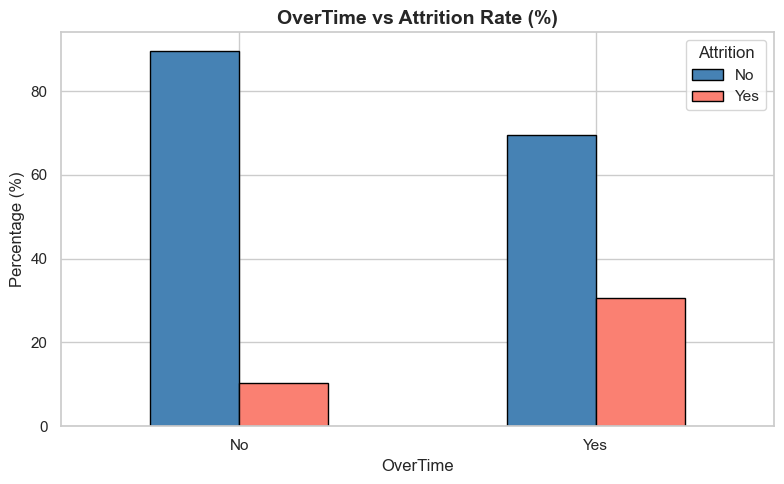


Insight: Employees who work overtime are significantly more likely to leave.


In [10]:
plt.figure(figsize=(8, 5))
overtime_attr = df.groupby(['OverTime', 'Attrition']).size().unstack(fill_value=0)
overtime_attr_pct = overtime_attr.div(overtime_attr.sum(axis=1), axis=0) * 100

overtime_attr_pct.plot(kind='bar', color=['steelblue', 'salmon'],
                        edgecolor='black', figsize=(8, 5))
plt.title('OverTime vs Attrition Rate (%)', fontsize=14, fontweight='bold')
plt.xlabel('OverTime')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Attrition', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

print("\nInsight: Employees who work overtime are significantly more likely to leave.")

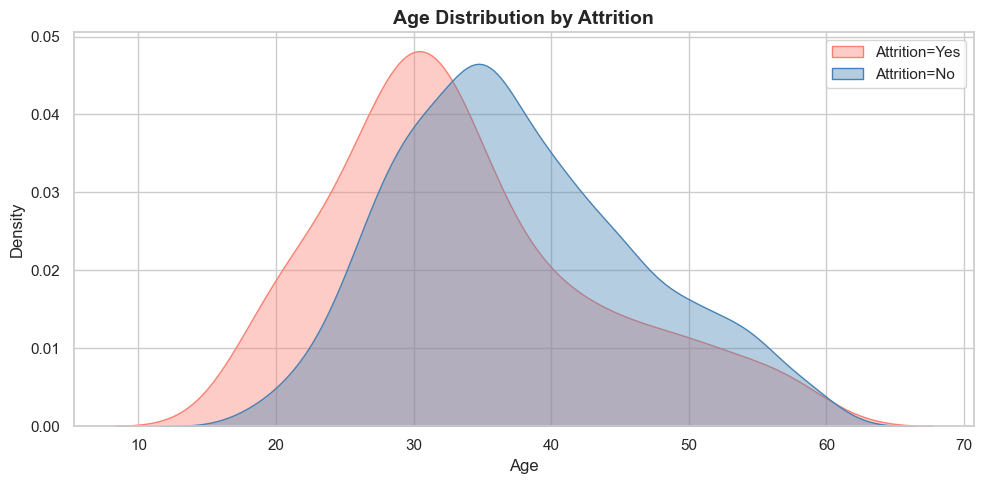


Insight: Younger employees (20–35) tend to leave more than older ones.


In [11]:
plt.figure(figsize=(10, 5))
for label, color in zip(['Yes', 'No'], ['salmon', 'steelblue']):
    subset = df[df['Attrition'] == label]['Age']
    sns.kdeplot(subset, label=f'Attrition={label}', fill=True, alpha=0.4, color=color)
plt.title('Age Distribution by Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

print("\nInsight: Younger employees (20–35) tend to leave more than older ones.")

4. Data Preprocessing

In [12]:
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

existing_drops = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=existing_drops, inplace=True)

print(f"Dropped columns: {existing_drops}")
print(f"Dataset shape after dropping: {df.shape}")

Dropped columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
Dataset shape after dropping: (1470, 31)


In [13]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"   [{col}] → filled with mode: '{df[col].mode()[0]}'")
        else:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"   [{col}] → filled with median: {df[col].median()}")

print(f"\nMissing values after handling: {df.isnull().sum().sum()}")


Missing values after handling: 0


In [14]:

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print("Attrition encoded: Yes=1, No=0")
print(df['Attrition'].value_counts())

Attrition encoded: Yes=1, No=0
Attrition
0    1233
1     237
Name: count, dtype: int64


In [15]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {cat_cols}\n")

le = LabelEncoder()
binary_encoded = []
onehot_encoded = []

for col in cat_cols:
    if df[col].nunique() == 2:
        df[col] = le.fit_transform(df[col])
        binary_encoded.append(col)
    else:
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat([df, dummies], axis=1)
        df.drop(columns=[col], inplace=True)
        onehot_encoded.append(col)

print(f"Label Encoded (binary):  {binary_encoded}")
print(f"One-Hot Encoded (multi): {onehot_encoded}")
print(f"\nDataset shape after encoding: {df.shape}")

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Label Encoded (binary):  ['Gender', 'OverTime']
One-Hot Encoded (multi): ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']

Dataset shape after encoding: (1470, 45)


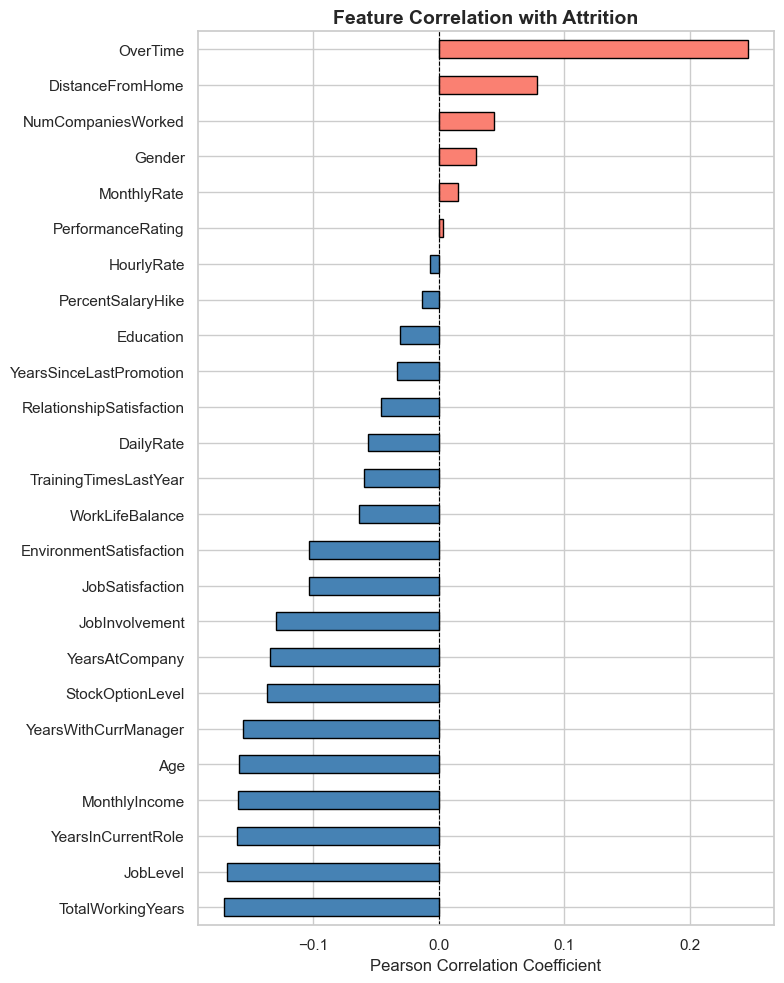


Top positive correlates (increase attrition risk):
MonthlyRate           0.015170
Gender                0.029453
NumCompaniesWorked    0.043494
DistanceFromHome      0.077924
OverTime              0.246118

Top negative correlates (decrease attrition risk):
TotalWorkingYears    -0.171063
JobLevel             -0.169105
YearsInCurrentRole   -0.160545
MonthlyIncome        -0.159840
Age                  -0.159205


In [16]:
numeric_df = df.select_dtypes(include=[np.number])

corr_with_target = numeric_df.corr()['Attrition'].drop('Attrition').sort_values()

plt.figure(figsize=(8, 10))
colors = ['salmon' if v > 0 else 'steelblue' for v in corr_with_target.values]
corr_with_target.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Correlation with Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

print("\nTop positive correlates (increase attrition risk):")
print(corr_with_target.tail(5).to_string())
print("\nTop negative correlates (decrease attrition risk):")
print(corr_with_target.head(5).to_string())

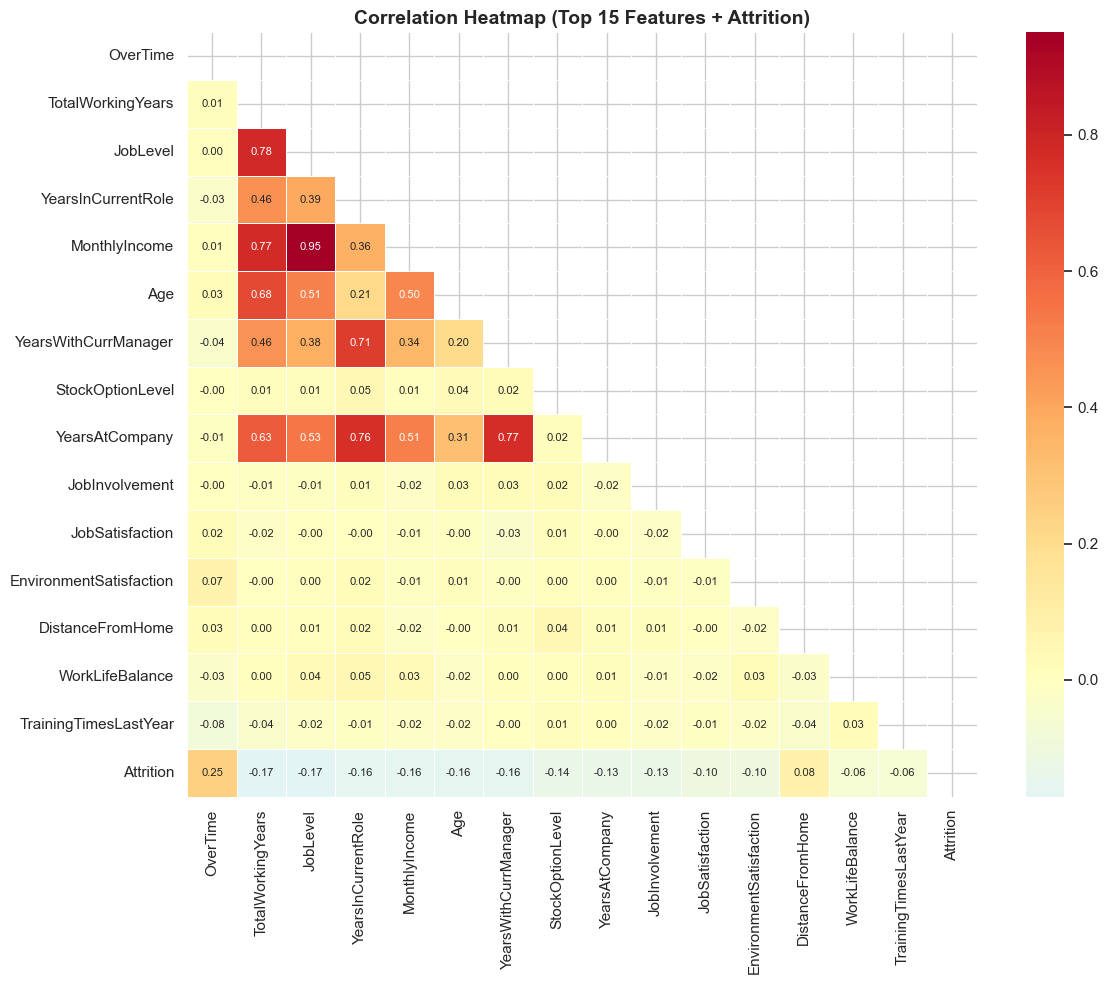

In [17]:
top_features = corr_with_target.abs().sort_values(ascending=False).head(15).index.tolist()
top_features.append('Attrition')

plt.figure(figsize=(12, 10))
corr_matrix = numeric_df[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap (Top 15 Features + Attrition)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

5. Feature Selection & Train-Test Split

In [18]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

print(f"Features (X): {X.shape[1]} columns, {X.shape[0]} rows")
print(f"Target   (y): {y.shape[0]} values")
print(f"\nClass distribution:")
print(f"   Stayed (0): {(y == 0).sum()} employees")
print(f"   Left   (1): {(y == 1).sum()} employees")

Features (X): 44 columns, 1470 rows
Target   (y): 1470 values

Class distribution:
   Stayed (0): 1233 employees
   Left   (1): 237 employees


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test  set: {X_test.shape[0]} samples")

Train set: 1176 samples
Test  set: 294 samples


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling applied (StandardScaler)")
print("   → Scaled data will be used for Logistic Regression")
print("   → Original data will be used for Decision Tree & Random Forest")

Feature scaling applied (StandardScaler)
   → Scaled data will be used for Logistic Regression
   → Original data will be used for Decision Tree & Random Forest


6. Model Building & Evaluation

In [21]:
def evaluate_model(model_name, y_true, y_pred):
    """Prints complete evaluation metrics for a model."""
    acc = accuracy_score(y_true, y_pred)
    cm  = confusion_matrix(y_true, y_pred)
    cr  = classification_report(y_true, y_pred, target_names=['Stayed', 'Left'])

    print(f"\n{'='*55}")
    print(f"  {model_name} — Evaluation Results")
    print(f"{'='*55}")
    print(f"  Accuracy Score: {acc*100:.2f}%")
    print(f"{'─'*55}")

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Stayed (0)', 'Left (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n  Classification Report:")
    print(cr)

    return acc

results = {}
print("Evaluation helper function defined.")

Evaluation helper function defined.



  Logistic Regression — Evaluation Results
  Accuracy Score: 86.05%
───────────────────────────────────────────────────────


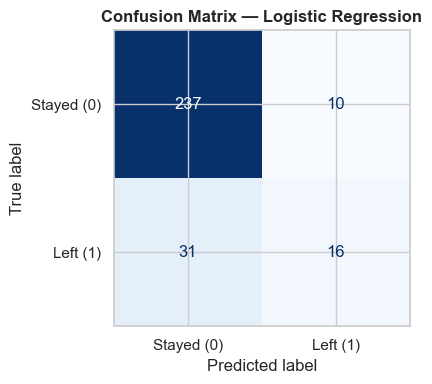


  Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92       247
        Left       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [22]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

acc_lr = evaluate_model('Logistic Regression', y_test, lr_pred)
results['Logistic Regression'] = round(acc_lr * 100, 2)


  Decision Tree Classifier — Evaluation Results
  Accuracy Score: 83.33%
───────────────────────────────────────────────────────


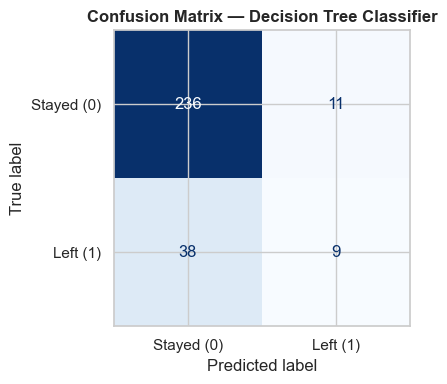


  Classification Report:
              precision    recall  f1-score   support

      Stayed       0.86      0.96      0.91       247
        Left       0.45      0.19      0.27        47

    accuracy                           0.83       294
   macro avg       0.66      0.57      0.59       294
weighted avg       0.80      0.83      0.80       294



In [23]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

acc_dt = evaluate_model('Decision Tree Classifier', y_test, dt_pred)
results['Decision Tree'] = round(acc_dt * 100, 2)


  Random Forest Classifier — Evaluation Results
  Accuracy Score: 82.65%
───────────────────────────────────────────────────────


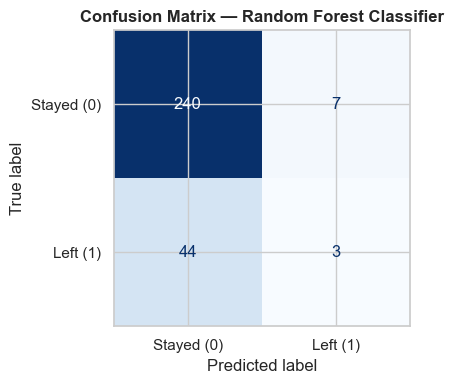


  Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.97      0.90       247
        Left       0.30      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.57      0.52      0.50       294
weighted avg       0.76      0.83      0.78       294



In [24]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

acc_rf = evaluate_model('Random Forest Classifier', y_test, rf_pred)
results['Random Forest'] = round(acc_rf * 100, 2)

7. Model Comparison

In [25]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy (%)': list(results.values())
}).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)

comparison_df.index += 1
comparison_df.index.name = 'Rank'

print("\n" + "="*45)
print("       MODEL COMPARISON TABLE")
print("="*45)
print(comparison_df.to_string())
print("="*45)
print(f"\nBest Model: {comparison_df.iloc[0]['Model']} ({comparison_df.iloc[0]['Accuracy (%)']:.2f}%)")


       MODEL COMPARISON TABLE
                    Model  Accuracy (%)
Rank                                   
1     Logistic Regression         86.05
2           Decision Tree         83.33
3           Random Forest         82.65

Best Model: Logistic Regression (86.05%)


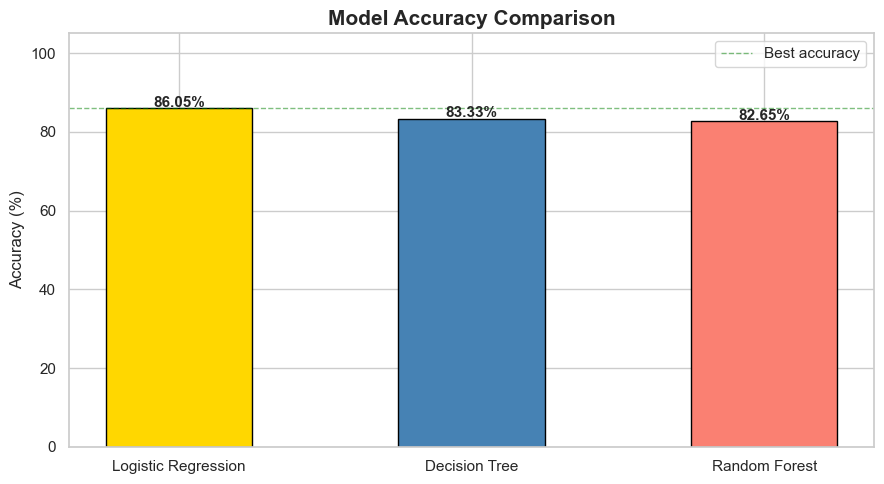

In [26]:
colors = ['gold', 'steelblue', 'salmon']
plt.figure(figsize=(9, 5))
bars = plt.bar(comparison_df['Model'], comparison_df['Accuracy (%)'],
               color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, comparison_df['Accuracy (%)']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{val:.2f}%', ha='center', fontweight='bold', fontsize=11)

plt.title('Model Accuracy Comparison', fontsize=15, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105)
plt.axhline(y=comparison_df['Accuracy (%)'].max(), color='green',
            linestyle='--', linewidth=1, alpha=0.5, label='Best accuracy')
plt.legend()
plt.tight_layout()
plt.show()

8. Feature Importance (Logistic Regression)

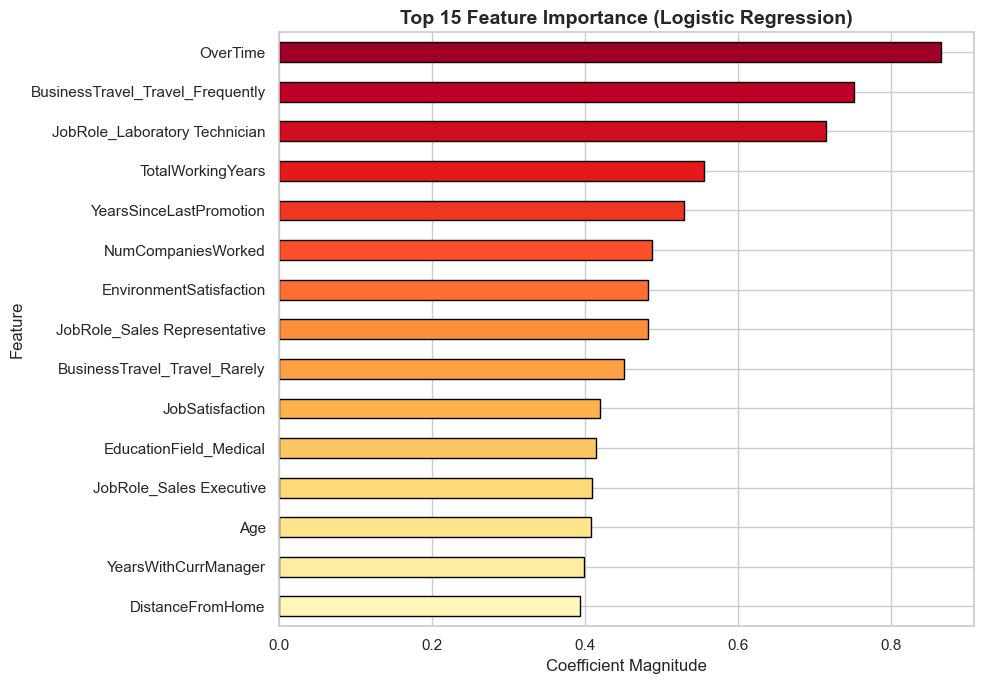


📊 Top 10 Most Important Features:
    1. OverTime                            → 0.8646
    2. BusinessTravel_Travel_Frequently    → 0.7512
    3. JobRole_Laboratory Technician       → 0.7148
    4. TotalWorkingYears                   → 0.5556
    5. YearsSinceLastPromotion             → 0.5287
    6. NumCompaniesWorked                  → 0.4876
    7. EnvironmentSatisfaction             → 0.4817
    8. JobRole_Sales Representative        → 0.4815
    9. BusinessTravel_Travel_Rarely        → 0.4501
   10. JobSatisfaction                     → 0.4194


In [27]:
feature_importances = pd.Series(
    lr_model.coef_[0], index=X.columns
)

feature_importances = feature_importances.abs().sort_values(ascending=False)

top15 = feature_importances.head(15)

plt.figure(figsize=(10, 7))
colors = sns.color_palette('YlOrRd_r', len(top15))
top15.plot(kind='barh', color=colors, edgecolor='black')

plt.title('Top 15 Feature Importance (Logistic Regression)',
          fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Magnitude')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n📊 Top 10 Most Important Features:")
for i, (feat, score) in enumerate(top15.head(10).items(), 1):
    print(f"   {i:2}. {feat:<35} → {score:.4f}")

9. Insights & Interpretation

In [28]:
best_model_name = comparison_df.iloc[0]['Model']
best_accuracy   = comparison_df.iloc[0]['Accuracy (%)']

print("\n" + "="*60)
print("  FINAL MODEL RECOMMENDATION")
print("="*60)
print(f"\n  Best Model : {best_model_name}")
print(f"  Accuracy   : {best_accuracy:.2f}%")
print()
print("  Why Logistic Regression is effective:")
print("  ✔ Simple and easy to interpret")
print("  ✔ Provides probability of attrition (risk score)")
print("  ✔ Works well for binary classification problems")
print("  ✔ Coefficients show impact of each feature clearly")
print()
print("  This model can help HR departments identify")
print("     employees with high probability of leaving early.")
print("="*60)


  FINAL MODEL RECOMMENDATION

  Best Model : Logistic Regression
  Accuracy   : 86.05%

  Why Logistic Regression is effective:
  ✔ Simple and easy to interpret
  ✔ Provides probability of attrition (risk score)
  ✔ Works well for binary classification problems
  ✔ Coefficients show impact of each feature clearly

  This model can help HR departments identify
     employees with high probability of leaving early.


10. Predict on a New Employee (Demo)

In [29]:
sample_employee = X_test.iloc[[0]].copy()

prob = rf_model.predict_proba(sample_employee)[0]
prediction = rf_model.predict(sample_employee)[0]

print("="*55)
print("  SAMPLE EMPLOYEE ATTRITION PREDICTION")
print("="*55)
print(f"  Probability of Staying  (0): {prob[0]*100:.1f}%")
print(f"  Probability of Leaving  (1): {prob[1]*100:.1f}%")
print(f"  Model Prediction            : {'Will LEAVE' if prediction == 1 else 'Will STAY'}")
print(f"  Actual Label                : {'Left (1)' if y_test.iloc[0] == 1 else 'Stayed (0)'}")
print("="*55)
print("\nIn production, HR teams can run this for every employee")
print("   and focus retention efforts on high-risk individuals.")

  SAMPLE EMPLOYEE ATTRITION PREDICTION
  Probability of Staying  (0): 47.0%
  Probability of Leaving  (1): 53.0%
  Model Prediction            : Will LEAVE
  Actual Label                : Stayed (0)

In production, HR teams can run this for every employee
   and focus retention efforts on high-risk individuals.
